In [20]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sequences import _load_sequence_dataframe, _load_signal_from_row
from config import load_class_info
from pathlib import Path

In [29]:
import pywt
def _wavelet_filter(data):
    maxlev = 5 # Override if desired
    wavelet = 'sym5'
    mode = 'symmetric'

    if len(data.shape) == 1:
        data = np.atleast_2d(data).T
    # Decompose into wavelet components, to the level selected
    coeffs = pywt.wavedec(data, wavelet, level=maxlev, mode=mode, axis=0)

    for j in range(0, data.shape[1]):
        dcoeffs = coeffs[-1][:,j]
        sigma = 1.4825 * np.median(np.abs(dcoeffs))
        uthresh = np.nan_to_num(sigma * np.sqrt(2*np.log(data.shape[0])))
        for i in range(1, maxlev + 1):
            coe = coeffs[i][:,j]
            c = pywt.threshold(coe, uthresh)
            coeffs[i][:,j] = np.nan_to_num(c)

    data = np.nan_to_num(pywt.waverec(coeffs, wavelet, mode=mode, axis=0))
    data = np.diff(data, axis=0)
    return np.squeeze(data)

In [80]:
DATA_FOLDER = Path("/tf/start_training/data/signal/2025-11-27_5clf_best_data")
LABEL = "car"
WINDOW_SIZE = 20000

df = _load_sequence_dataframe(DATA_FOLDER / "train.csv")
class_info = load_class_info(DATA_FOLDER)
classes = class_info.classes

walk_df = df[df["event"] == LABEL].reset_index(drop=True)
filtered_walk_df = walk_df[~walk_df['file'].str.contains('cross|italy', case=False, na=False)].reset_index(drop=True)

In [22]:
row = filtered_walk_df.sample(1).iloc[0]
data = _load_signal_from_row(row, WINDOW_SIZE).astype(np.float32)

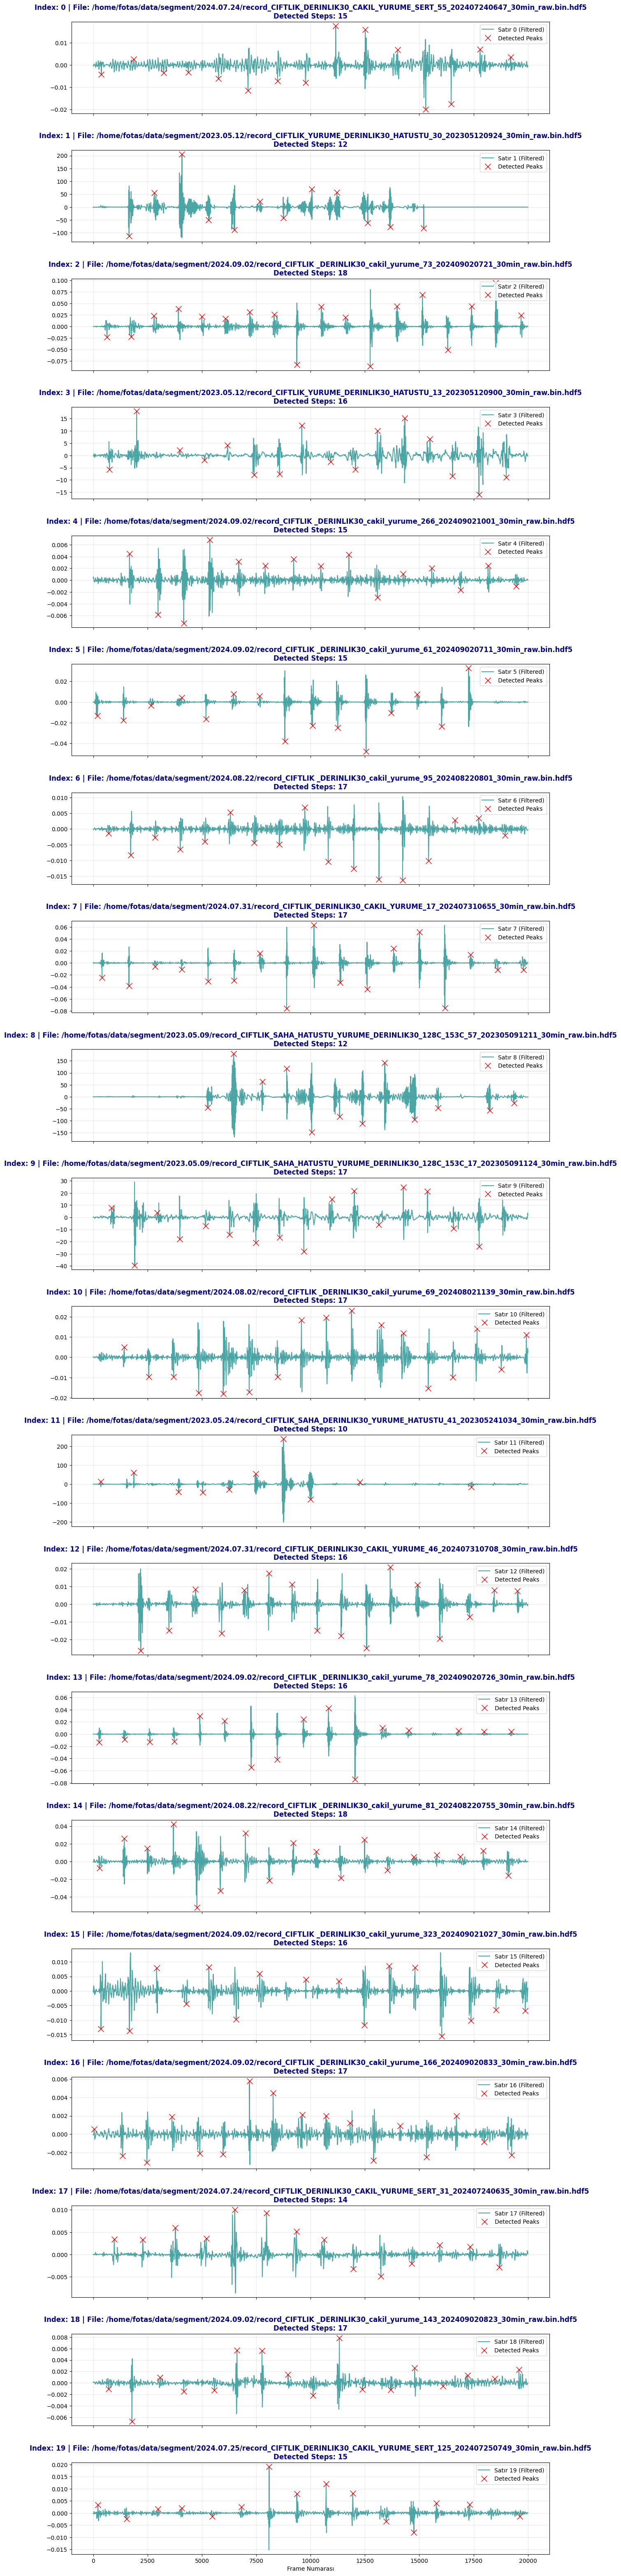

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- AYARLAR ---
start_idx = 0  # Başlangıç satırı (Örn: 0, 10, 20...)
count = 20     # Kaç adet çizilecek
end_idx = start_idx + count

# Görselleştirme
fig, axes = plt.subplots(count, 1, figsize=(15, 4 * count), sharex=True)
plt.subplots_adjust(hspace=0.4)

if count == 1: axes = [axes] # Tek bir grafik çizilirse hata almamak için

for i, idx in enumerate(range(start_idx, end_idx)):
    # 1. Veriyi Oku (Sabit İndeks)
    row = filtered_walk_df.iloc[idx]
    filename = row['file']
    data = _load_signal_from_row(row, WINDOW_SIZE).astype(np.float32)
    # 2. Wavelet Filter
    filtered_signal = _wavelet_filter(data)
    abs_filtered = np.abs(filtered_signal)
    # 3. Peak Detection
    peaks, _ = find_peaks(abs_filtered, distance=1000, prominence=np.std(abs_filtered)*1.3)
    # 4. Plotting
    ax = axes[i]
    ax.plot(filtered_signal, label=f'Satır {idx} (Filtered)', color='teal', alpha=0.7)
    ax.plot(peaks, filtered_signal[peaks], "rx", markersize=10, label='Detected Peaks')
    ax.set_title(f"Index: {idx} | File: {filename}\nDetected Steps: {len(peaks)}", 
                 fontsize=12, fontweight='bold', color='navy')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
plt.xlabel("Frame Number")
plt.show()

In [84]:
import pandas as pd
import numpy as np
import os
from scipy.signal import find_peaks

def process_and_save_peaks(file_path, save_name):
    # 1. CSV'yi yükle
    df = pd.read_csv(file_path)
    
    # 2. Filtreleme: Sadece ilgili LABEL ve içinde cross/italy geçmeyenler
    # Not: Eğer diğer event'leri de tutmak istersen LABEL filtresini kaldırabilirsin
    mask = (df["event"] == LABEL) & (~df['file'].str.contains('cross|italy', case=False, na=False))
    filtered_df = df[mask].copy().reset_index(drop=True)
    
    all_peaks_list = []
    
    print(f"{file_path} işleniyor... Toplam satır: {len(filtered_df)}")
    
    # 3. Her satır için peak hesapla
    for idx, row in filtered_df.iterrows():
        try:
            # Veriyi yükle
            data = _load_signal_from_row(row, WINDOW_SIZE).astype(np.float32)
            
            # Filtrele
            filtered_signal = _wavelet_filter(data)
            abs_filtered = np.abs(filtered_signal)
            
            # Peak bul (Önceki testlerde belirlediğin en iyi parametreleri yaz)
            peaks, _ = find_peaks(abs_filtered, distance=1000, prominence=np.std(abs_filtered)*1.3)
            
            # Peak frame numaralarını string olarak saklamak CSV için daha güvenlidir
            # Örn: "120,450,890"
            peaks_str = ",".join(map(str, peaks))
            all_peaks_list.append(peaks_str)
            
        except Exception as e:
            print(f"Hata! Indeks {idx}, Dosya {row['file']}: {e}")
            all_peaks_list.append("") # Hata durumunda boş bırak

    # 4. Yeni sütunu ekle
    filtered_df['peaks'] = all_peaks_list
    
    # 5. Yeni CSV olarak kaydet
    filtered_df.to_csv(save_name, index=False)
    print(f"Tamamlandı: {save_name} kaydedildi.\n")

# --- ANA DÖNGÜ ---
files_to_process = {
    'train.csv': 'train_with_peaks.csv',
    'test.csv': 'test_with_peaks.csv',
    'validation.csv': 'val_with_peaks.csv'
}


for original, new_name in files_to_process.items():
    full_path = os.path.join(DATA_FOLDER, original)
    if os.path.exists(full_path):
        process_and_save_peaks(full_path, new_name)

/tf/start_training/data/signal/2025-11-27_5clf_best_data/train.csv işleniyor... Toplam satır: 11733
Tamamlandı: train_with_peaks.csv kaydedildi.

/tf/start_training/data/signal/2025-11-27_5clf_best_data/test.csv işleniyor... Toplam satır: 943
Tamamlandı: test_with_peaks.csv kaydedildi.

/tf/start_training/data/signal/2025-11-27_5clf_best_data/validation.csv işleniyor... Toplam satır: 1006
Tamamlandı: val_with_peaks.csv kaydedildi.

